In [4]:
import numpy as np
import rasterio
import json
import geopandas as gpd
from shapely.geometry import mapping
from shapely.geometry import box
from shapely.geometry import Point
from rasterio.plot import show
import matplotlib.pyplot as plt

# Prepare Shapes for Drone Routing

In [5]:
# Load the California 2024 shapefile
tract_gdf = gpd.read_file("data/tl_2024_06_tract/tl_2024_06_tract.shp")

# Inspect the data
print(tract_gdf.head())
print(tract_gdf.crs)  # Coordinate Reference System

DataSourceError: data/tl_2024_06_tract/tl_2024_06_tract.shp: No such file or directory

<Axes: >

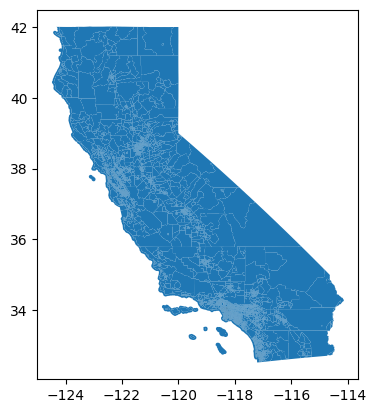

In [3]:
tract_gdf.plot()

In [ ]:
# Load the Urban Area Criteria 2024 shapefile
urban_gdf = gpd.read_file("data/tl_2024_us_uac20/tl_2024_us_uac20.shp")

# Inspect the data
print(urban_gdf.head())
print(urban_gdf.crs) 

(30.0, 50.0)

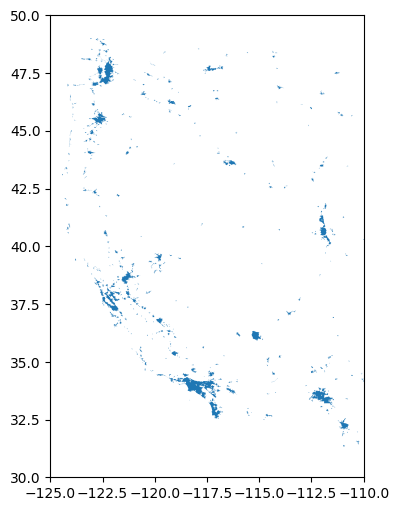

In [5]:
ax = urban_gdf.plot(figsize=(8, 6))
ax.set_xlim(-125, -110)
# set Y too (otherwise autoscale may override)
ax.set_ylim(30, 50)

In [6]:
# fix invalid geometries
tract_gdf["geometry"] = tract_gdf.buffer(0)
urban_gdf["geometry"] = urban_gdf.buffer(0)


# Spatial difference via overlay
result = gpd.overlay(tract_gdf, urban_gdf, how="difference")
result.to_file("CA_minus_urban.shp")

# Subtract: difference each feature in A by the union of B
# result = tract_gdf.copy()
# result["geometry"] = result.geometry.difference(urban_gdf.unary_union)

<Axes: >

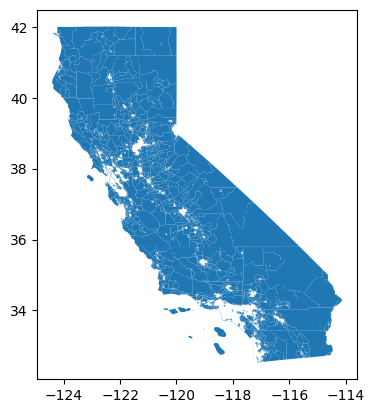

In [16]:
result.plot()

## Get Land Area

In [44]:
# result[10:11]['land_km2']

result[4:5]['land_km2'] #.plot()

4    39.811222
Name: land_km2, dtype: float64

In [ ]:
# Get area in km²
result["land_km2"] = result["ALAND"] / 1_000_000

# (1) Allocation of resources based on area
# total_resources = 1000  # e.g., 1000 drones

# (2) More resources to higher risk areas eg more fires

In [14]:
# Keep only polygons with land area
result = result[result["ALAND"] > 0]

# (Optional) drop tiny islands or artifacts if needed
result = result[result["ALAND"] > 1_000]  # > 1,000 m², for example

## Selected Fires

In [8]:
latitude = 40.53927
longitude = -122.56656 # https://en.wikipedia.org/wiki/Zogg_Fire

latitude =39.243283
longitude = -123.103367 # https://en.wikipedia.org/wiki/Mendocino_Complex_Fire

latitude =34.2350
longitude = -118.7013 # https://en.wikipedia.org/wiki/Woolsey_Fire

latitude = 39.765
longitude = -122.673 # https://en.wikipedia.org/wiki/August_Complex_fire

latitude = 34.679
longitude = -118.452 # https://en.wikipedia.org/wiki/Lake_Fire_(2020)

point = Point(longitude, latitude)

In [9]:
if result.crs != "EPSG:4326":
    gdf = result.to_crs(epsg=4326)

NameError: name 'result' is not defined

In [10]:
# Boolean mask
mask = result.contains(point)

# Extract the matching shape
selected = result[mask]

if not selected.empty:
    print("Found polygon:")
    print(selected)
else:
    print("Point is not inside any polygon.")

NameError: name 'result' is not defined

In [11]:
selected

NameError: name 'selected' is not defined

NameError: name 'gdf' is not defined

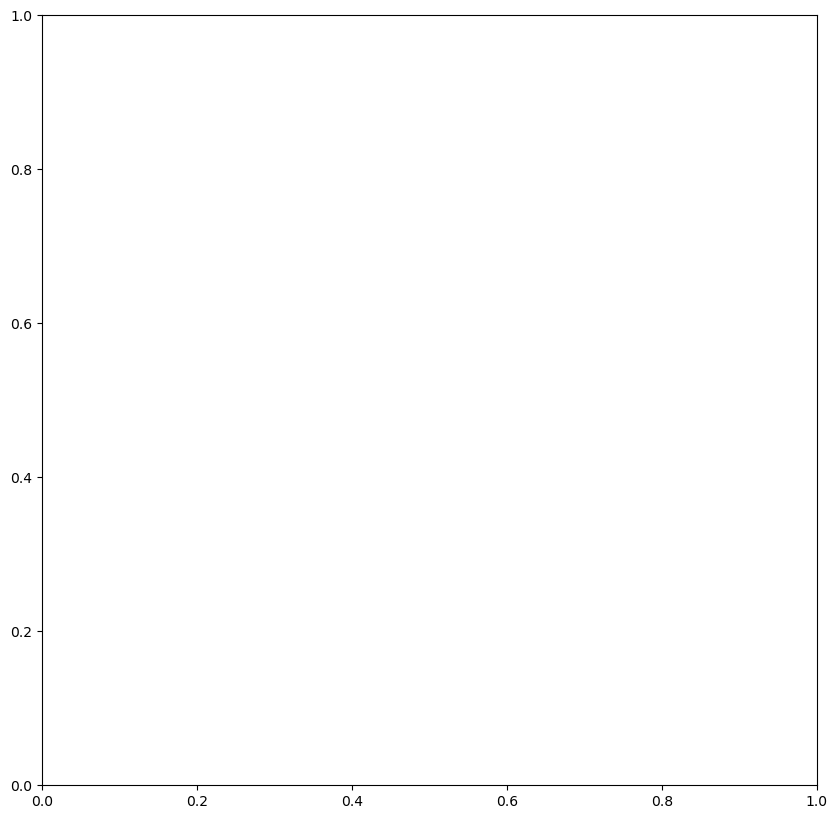

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot shapefile
gdf.plot(ax=ax, color="lightgray", edgecolor="black")

selected.plot(ax=ax, color="yellow", edgecolor="red")
# Plot the point
point_gdf = gpd.GeoDataFrame(
    {"name": ["My Point"]},
    geometry=[point],
    crs="EPSG:4326"
)
point_gdf.plot(ax=ax, color="red", markersize=80)

# Annotate the point
# ax.annotate("My Point", xy=(longitude, latitude), xytext=(3, 3), textcoords="offset points")

# Styling
ax.set_title("Fire location on the Map", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

## Get Risk Map

In [13]:
raster_path = '../../wildfire-risk/data/Data-2/whp2023_GeoTIF/whp2023_cnt_conus.tif'

# BP
raster_path = '../../wildfire-risk/data/CA-2/BP_CA.tif'

In [14]:
gdf = selected

NameError: name 'selected' is not defined

In [15]:
from rasterio.mask import mask

In [16]:
# (Optional) If there are many polygons and you want one crop, dissolve to one geometry
# e.g., dissolve by a constant or attribute; here we dissolve everything into one shape
geom = gdf.union_all()  # returns a (multi)polygon
geoms = [mapping(geom)] # mask() expects GeoJSON-like mappings

with rasterio.open(raster_path) as src:
    # Reproject vector to raster CRS if needed
    if gdf.crs != src.crs:
        gdf = gdf.to_crs(src.crs)
        geoms = [mapping(gdf.union_all())]

    # ---------------------------
    # Clip raster to geometry
    # ---------------------------
    # crop=True trims to the minimal bounding window around the geometry
    # all_touched=True includes any pixel touched by the polygon boundary (optional)
    out_arr, out_transform = mask(
        src, geoms, crop=True, nodata=src.nodata, all_touched=False
    )

    out_meta = src.meta.copy()
    out_meta.update({
        "height": out_arr.shape[1],
        "width":  out_arr.shape[2],
        "transform": out_transform
    })

# ---------------------------
# Write clipped GeoTIFF
# ---------------------------
out_path = "risk_layouts/california/BP_cnt_conus_CLIP_Lake_Fire.tif" 
with rasterio.open(out_path, "w", **out_meta) as dst:
    dst.write(out_arr)

print(f"Saved clipped raster → {out_path}")

NameError: name 'gdf' is not defined

EPSG:5070


NameError: name 'point_gdf' is not defined

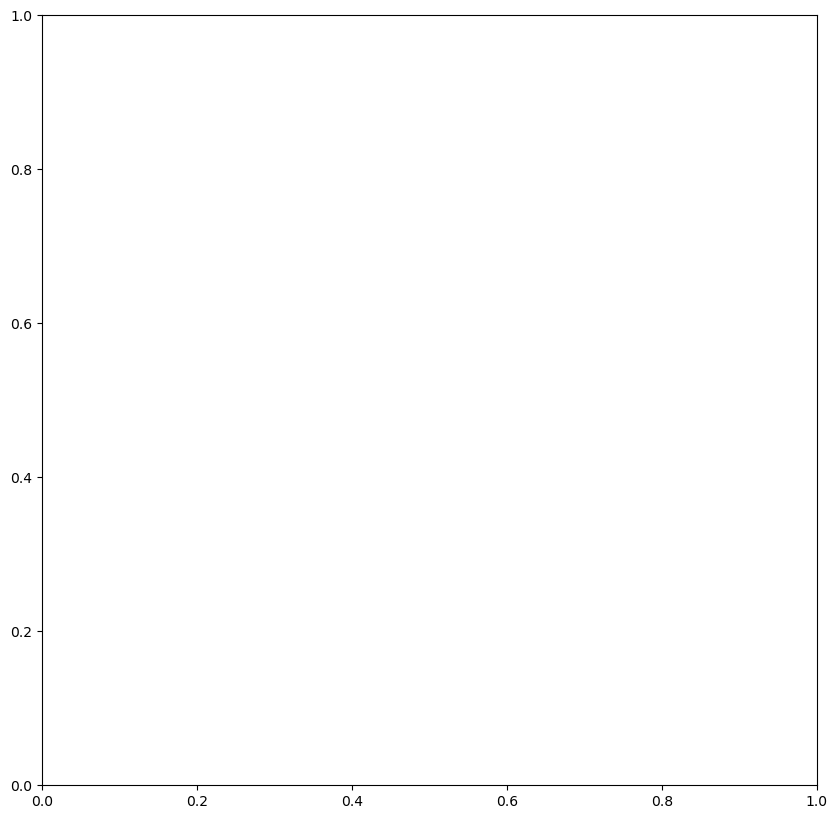

In [19]:
out_path = "risk_layouts/california/BP_cnt_conus_CLIP_Lake_Fire.tif" 
fig, ax = plt.subplots(figsize=(10, 10))


with rasterio.open(out_path) as src:
    print(src.crs)
    point = point_gdf.to_crs(src.crs)
    point.plot(ax=ax, color="red", markersize=80)

    data = src.read(1).astype(float)
    data[data == src.nodata] = np.nan
    
    plt.imshow(data, cmap='inferno', vmin=np.nanpercentile(data, 2), vmax=np.nanpercentile(data, 98))

    img = ax.imshow(
        data,
        cmap="inferno",
        extent=(
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top,
        ),
        vmin=np.nanpercentile(data, 2),
        vmax=np.nanpercentile(data, 98),
    )
    plt.colorbar(img, ax=ax, label="Hazard intensity")
    # Plot point
    ax.legend()
plt.show()

(30.0, 30.0)
BoundingBox(left=-2051535.0, bottom=1510695.0, right=-2016195.0, top=1546485.0)
EPSG:5070


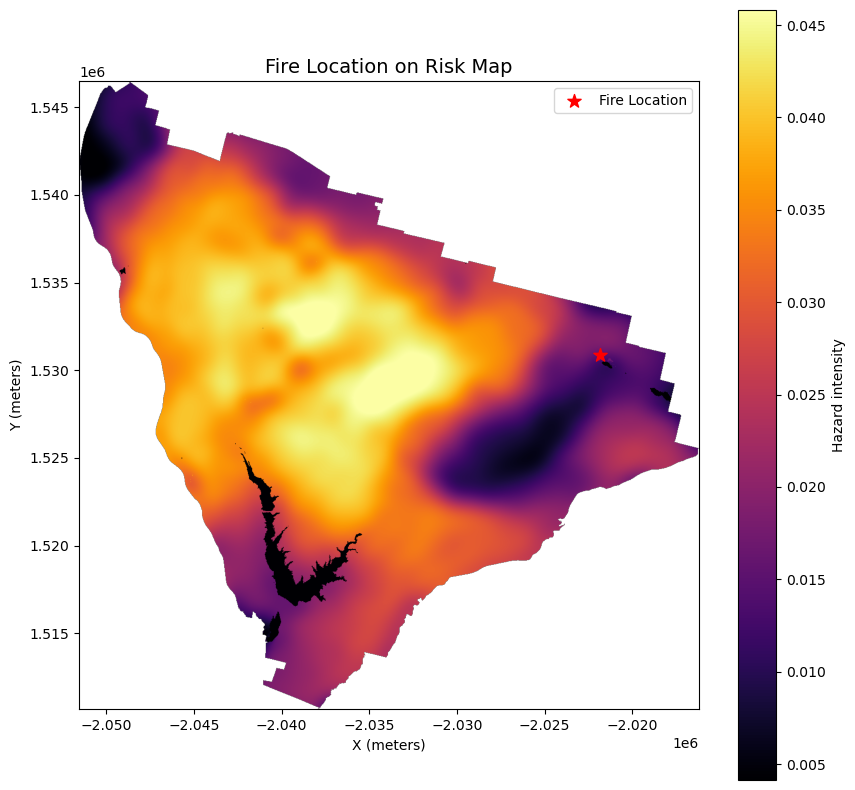

In [64]:
# open the tif file
with rasterio.open(out_path) as src:
    # print the resolution
    print(src.res)
    # print the bounds
    print(src.bounds)
    # print the crs
    print(src.crs)
    # plot the tiff
    point_gdf = gpd.GeoDataFrame(
        {"name": ["My Point"]},
        geometry=[point],
        crs="EPSG:4326"
    )
    
    # Convert point to raster CRS
    point_gdf_reprojected = point_gdf.to_crs(src.crs)
    
    # Read raster data
    data = src.read(1).astype(float)
    data[data == src.nodata] = np.nan
    
    # Create figure and plot
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Plot the raster
    img = ax.imshow(
        data,
        cmap="inferno",
        extent=(
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top,
        ),
        vmin=np.nanpercentile(data, 2),
        vmax=np.nanpercentile(data, 98),
    )
    
    # Plot the point overlaid on the map
    point_gdf_reprojected.plot(ax=ax, color="red", markersize=100, marker="*", label="Fire Location")
    
    # Add colorbar and labels
    plt.colorbar(img, ax=ax, label="Hazard intensity")
    ax.set_title("Fire Location on Risk Map", fontsize=14)
    ax.set_xlabel("X (meters)")
    ax.set_ylabel("Y (meters)")
    ax.legend()
    
    plt.show()
    

In [21]:
import os
def convert_tif_to_npy(input_folder, output_folder):
    """
    Convert all .tif or .tiff files in a folder to .npy format.

    Args:
        input_folder (str): Path to the directory containing .tif/.tiff files.
        output_folder (str): Path to the directory where .npy files will be saved.
        max_files (int, optional): Maximum number of .tif files to process. If None, process all files.

    Yields:
        str: Path to each .npy file created.
    """
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    for file in os.listdir(input_folder):
        if file.lower().endswith('.tif') or file.lower().endswith('.tiff'):
            tif_path = os.path.join(input_folder, file)
            with rasterio.open(tif_path) as src:
                data = src.read(1)  # Read the first band
                # duplicate the data to go from shape (N,M) to shape (100,N,M)
                data = np.tile(data, (1, 1, 1))
                print(data.shape)

            npy_filename = os.path.splitext(file)[0] + '.npy'
            np.save(os.path.join(output_folder, npy_filename), data)
            print(f"Converted {file} to {npy_filename}")

In [25]:
convert_tif_to_npy('./risk_layouts/california', './risk_layouts/npy_files')

(1, 2067, 2252)
Converted BP_cnt_conus_CLIP_August_Complex_fire.tif to BP_cnt_conus_CLIP_August_Complex_fire.npy
(1, 1964, 2267)
Converted BP_cnt_conus_CLIP_Zogg_Fire.tif to BP_cnt_conus_CLIP_Zogg_Fire.npy
(1, 1258, 553)
Converted BP_cnt_conus_CLIP_Mendocino_Complex_Fire.tif to BP_cnt_conus_CLIP_Mendocino_Complex_Fire.npy
(1, 1193, 1178)
Converted BP_cnt_conus_CLIP_Lake_Fire.tif to BP_cnt_conus_CLIP_Lake_Fire.npy
(1, 227, 379)
Converted BP_cnt_conus_CLIP_Woolsey_Fire.tif to BP_cnt_conus_CLIP_Woolsey_Fire.npy


(1, 1193, 1178)


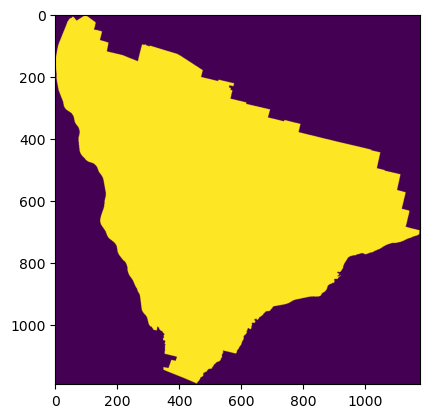

In [26]:
# open npy file
data = np.load('./risk_layouts/npy_files/BP_cnt_conus_CLIP_Lake_Fire.npy')
print(data.shape)
# plot the data
plt.imshow(data[0])
plt.show()

(1, 1193, 1178)
(582, 579)
0.0 0.04802963


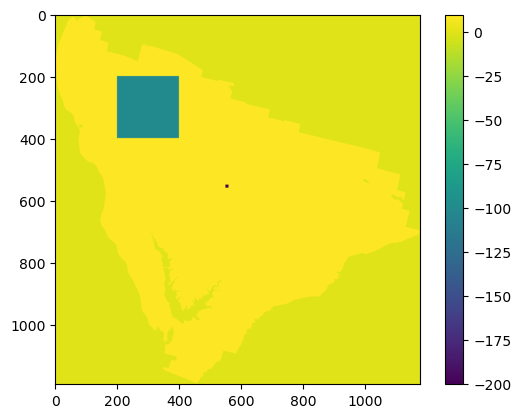

In [57]:
print(data.shape)
a = np.unravel_index(np.argmax(data[0]), data[0].shape)
print(a)
print(data[0].min(), data[0].max())
data[0][200:400,200:400] = np.min(data[0]) - 100  # Much lower than any existing value
data[0][550:560,550:560] = np.min(data[0]) - 100  # Much lower than any existing value

data[data > 0] = 10


plt.imshow(data[0])
plt.colorbar()
plt.show()

In [67]:
# Process all fires and create npy files
import os

# Fire information: (name, latitude, longitude, tiff_filename)
fires = [
    ("Lake_Fire", 34.679, -118.452, "BP_cnt_conus_CLIP_Lake_Fire.tif"),
    ("August_Complex_fire", 39.765, -122.673, "BP_cnt_conus_CLIP_August_Complex_fire.tif"),
    ("Woolsey_Fire", 34.2350, -118.7013, "BP_cnt_conus_CLIP_Woolsey_Fire.tif"),
    ("Mendocino_Complex_Fire", 39.243283, -123.103367, "BP_cnt_conus_CLIP_Mendocino_Complex_Fire.tif"),
    ("Zogg_Fire", 40.53927, -122.56656, "BP_cnt_conus_CLIP_Zogg_Fire.tif"),
]

base_dir = "risk_layouts/california"
output_base = "."

for fire_name, latitude, longitude, tiff_filename in fires:
    print(f"\nProcessing {fire_name}...")
    
    # Create output directory
    fire_dir = os.path.join(output_base, fire_name)
    scenarios_dir = os.path.join(fire_dir, "Satellite_Images_Mask")
    os.makedirs(scenarios_dir, exist_ok=True)
    
    # Path to tiff file
    tiff_path = os.path.join(base_dir, tiff_filename)
    
    # Open raster and process
    with rasterio.open(tiff_path) as src:
        # Read raster data
        data = src.read(1).astype(np.float32)  # Read first band
        
        # Get nodata value
        nodata = src.nodata
        
        # 2. Create mask.npy: 1 if >= 0, 0 if < 0 (use original data before any processing)
        mask = np.ones_like(data, dtype=np.float32)
        mask[data < 0] = 0
        # Also set mask to 0 where data is nodata
        if nodata is not None:
            mask[data == nodata] = 0
        
        # Handle nodata values (set to NaN for processing)
        if nodata is not None:
            data[data == nodata] = np.nan
        
        # 1. Create burn_map.npy: cap values from below at 0
        burn_map = data.copy()
        burn_map = np.maximum(burn_map, 0)  # Cap at 0 from below
        # Replace NaN with 0 for burn_map
        burn_map = np.nan_to_num(burn_map, nan=0.0)
        
        # Save burn_map.npy (2D array)
        burn_map_path = os.path.join(fire_dir, "burn_map.npy")
        np.save(burn_map_path, burn_map)
        print(f"  Saved burn_map.npy: shape {burn_map.shape}")
        
        mask_path = os.path.join(fire_dir, "mask.npy")
        np.save(mask_path, mask)
        print(f"  Saved mask.npy: shape {mask.shape}")
        
        # 3. Create scenario1.npy: find point location and create (12, height, width) array
        # Create point in EPSG:4326
        point = Point(longitude, latitude)
        point_gdf = gpd.GeoDataFrame(
            {"name": ["Fire Point"]},
            geometry=[point],
            crs="EPSG:4326"
        )
        
        # Convert point to raster CRS
        point_gdf_reprojected = point_gdf.to_crs(src.crs)
        point_coords = point_gdf_reprojected.geometry.iloc[0]
        
        # Convert point coordinates to row/col indices
        row, col = rasterio.transform.rowcol(src.transform, point_coords.x, point_coords.y)
        
        # Check if point is within raster bounds
        height, width = data.shape
        if 0 <= row < height and 0 <= col < width:
            # Create scenario array: (12, height, width) with all zeros
            scenario = np.zeros((12, height, width), dtype=np.float32)
            # Set the point's cell to 1 in all 12 time steps
            scenario[:, row, col] = 1.0
            
            scenario_path = os.path.join(scenarios_dir, "scenario1.npy")
            np.save(scenario_path, scenario)
            print(f"  Saved scenarios/scenario1.npy: shape {scenario.shape}, point at (row={row}, col={col})")
        else:
            print(f"  WARNING: Point ({row}, {col}) is outside raster bounds ({height}, {width})")
            # Still create the scenario array with all zeros
            scenario = np.zeros((12, height, width), dtype=np.float32)
            scenario_path = os.path.join(scenarios_dir, "scenario1.npy")
            np.save(scenario_path, scenario)
            print(f"  Saved scenarios/scenario1.npy: shape {scenario.shape} (all zeros - point outside bounds)")

print("\nAll fires processed")




Processing Lake_Fire...
  Saved burn_map.npy: shape (1193, 1178)
  Saved mask.npy: shape (1193, 1178)
  Saved scenarios/scenario1.npy: shape (12, 1193, 1178), point at (row=521, col=989)

Processing August_Complex_fire...
  Saved burn_map.npy: shape (2067, 2252)
  Saved mask.npy: shape (2067, 2252)
  Saved scenarios/scenario1.npy: shape (12, 2067, 2252), point at (row=328, col=770)

Processing Woolsey_Fire...
  Saved burn_map.npy: shape (227, 379)
  Saved mask.npy: shape (227, 379)
  Saved scenarios/scenario1.npy: shape (12, 227, 379), point at (row=72, col=148)

Processing Mendocino_Complex_Fire...
  Saved burn_map.npy: shape (1258, 553)
  Saved mask.npy: shape (1258, 553)
  Saved scenarios/scenario1.npy: shape (12, 1258, 553), point at (row=1020, col=118)

Processing Zogg_Fire...
  Saved burn_map.npy: shape (1964, 2267)
  Saved mask.npy: shape (1964, 2267)
  Saved scenarios/scenario1.npy: shape (12, 1964, 2267), point at (row=1268, col=1606)

All fires processed


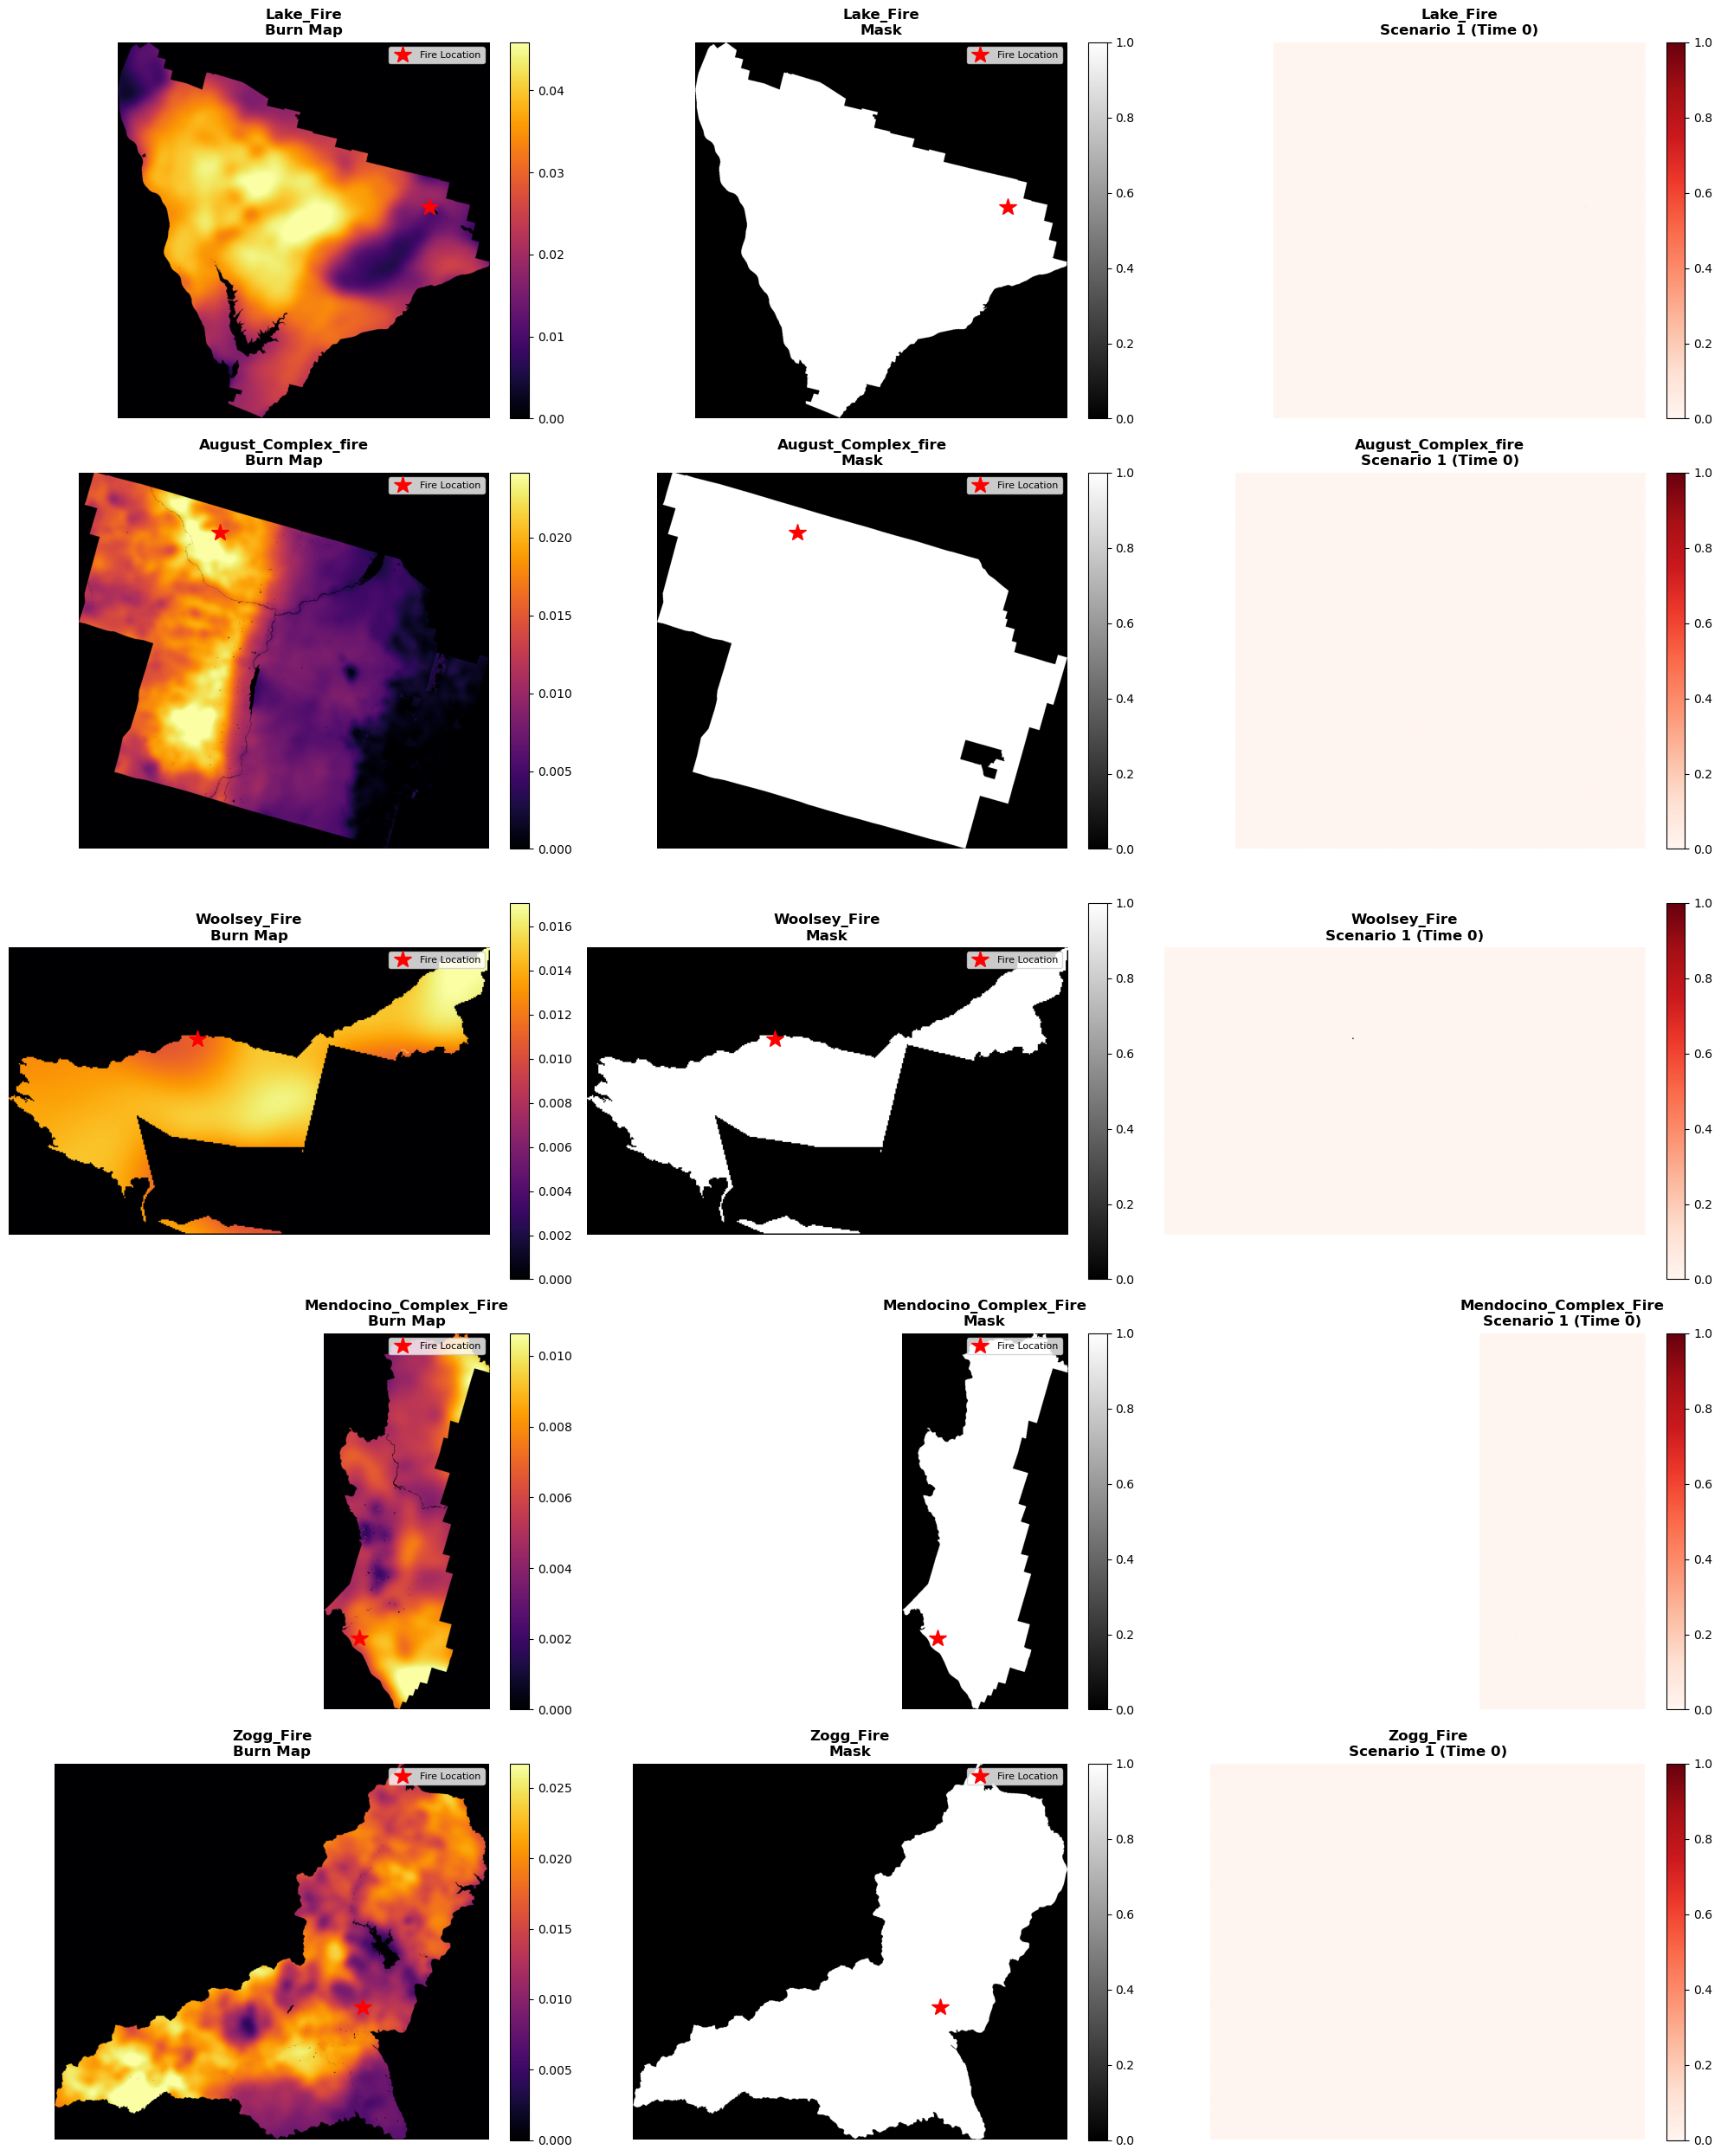

In [69]:
# Plot all fires: burn_map, mask, and scenario
fire_names = ["Lake_Fire", "August_Complex_fire", "Woolsey_Fire", "Mendocino_Complex_Fire", "Zogg_Fire"]

fig = plt.figure(figsize=(20, 25))

for idx, fire_name in enumerate(fire_names):
    fire_dir = fire_name
    
    # Load the npy files
    burn_map = np.load(os.path.join(fire_dir, "burn_map.npy"))
    mask = np.load(os.path.join(fire_dir, "mask.npy"))
    scenario = np.load(os.path.join(fire_dir, "Satellite_Images_Mask", "scenario1.npy"))
    
    # Find the point location from scenario
    point_locs = np.where(scenario[0] == 1)
    if len(point_locs[0]) > 0:
        point_row, point_col = point_locs[0][0], point_locs[1][0]
    else:
        point_row, point_col = None, None
    
    # Plot burn_map
    ax1 = plt.subplot(5, 3, idx * 3 + 1)
    im1 = ax1.imshow(burn_map, cmap='inferno', vmin=0, vmax=np.nanpercentile(burn_map[burn_map > 0], 98) if np.any(burn_map > 0) else 1)
    if point_row is not None:
        ax1.plot(point_col, point_row, 'r*', markersize=15, label='Fire Location')
    ax1.set_title(f'{fire_name}\nBurn Map', fontsize=12, fontweight='bold')
    ax1.axis('off')
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    if point_row is not None:
        ax1.legend(loc='upper right', fontsize=8)
    
    # Plot mask
    ax2 = plt.subplot(5, 3, idx * 3 + 2)
    im2 = ax2.imshow(mask, cmap='gray', vmin=0, vmax=1)
    if point_row is not None:
        ax2.plot(point_col, point_row, 'r*', markersize=15, label='Fire Location')
    ax2.set_title(f'{fire_name}\nMask', fontsize=12, fontweight='bold')
    ax2.axis('off')
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    if point_row is not None:
        ax2.legend(loc='upper right', fontsize=8)
    
    # Plot scenario (first time step)
    ax3 = plt.subplot(5, 3, idx * 3 + 3)
    im3 = ax3.imshow(scenario[0], cmap='Reds', vmin=0, vmax=1)
    ax3.set_title(f'{fire_name}\nScenario 1 (Time 0)', fontsize=12, fontweight='bold')
    ax3.axis('off')
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()




In [70]:
# Create config_california_historical.json with random offsets for each fire
import json
import random

fire_names = ["Lake_Fire", "August_Complex_fire", "Woolsey_Fire", "Mendocino_Complex_Fire", "Zogg_Fire"]

# Generate random offsets between 1 and 12 for each fire
config = {}
for fire_name in fire_names:
    config[f"offset_{fire_name}"] = random.randint(1, 12)

# Save to JSON file
config_path = "config_california_historical.json"
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print("Created config_california_historical.json:")
print(json.dumps(config, indent=2))



Created config_california_historical.json:
{
  "offset_Lake_Fire": 1,
  "offset_August_Complex_fire": 4,
  "offset_Woolsey_Fire": 7,
  "offset_Mendocino_Complex_Fire": 5,
  "offset_Zogg_Fire": 6
}
